# PaNS – Cvičenie: Iris (CSV) → DataLoader → neurónka (PyTorch) (binary cross-entropy)
## Binárna klasifikácia s jediným výstupným neurónom

**Cieľ:** Na datasete **Iris** s **dvoma triedami** si po malých krokoch postavíme celý proces:
1. načítanie dát z **CSV**
2. príprava vstupov **X** a labelov **y**
3. kódovanie tried (string → integer)
4. rozdelenie na **train / val / test** (stratifikácia)
5. **štandardizácia** (mean/std len z train)
6. `TensorDataset` + `DataLoader`
7. model: **1× fully-connected** `Linear(4 → 1)`
8. učenie s **binary cross-entropy**
9. sledovanie metrík: `accuracy`, `precision`, `recall`, `F1`, `confusion matrix`

> Dôraz je na vytvorenie loadera a na to, ako sa z CSV dostaneme až k trénovaniu klasifikačného modelu.
>
> Bunky **1 až 6** ostali v tejto verzii notebooku zámerne veľmi podobné pôvodnému ladiacemu notebooku.
> Od bunky **7** však už ideme čisto do **binárnej klasifikácie s jedným výstupným neurónom**.

> Poznámka: keďže bunky **1 až 6** ostali takmer bez zmeny, nájdeš tam aj pomocné objekty navyše (napr. one-hot reprezentáciu). Pri samotnom učení ich však nepoužijeme ako hlavný target pre loss.


---
## 0) Setup


In [7]:
# @title Imports + nastavenia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# from google.colab import drive
# drive.mount('/content/drive')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# csv_path = "/content/drive/MyDrive/PANS cvičenia/Cvičenie 4/Iris-two-class-versicolor-virginica.csv"
csv_path = "./Iris-two-class-setosa-virginica.csv"


Device: cpu


---
## 1) Načítanie Iris z CSV + kontrola

**Úloha (študent):**
- načítaj CSV do `df`
- pozri `head()`, `info()`
- skontroluj, či dataset obsahuje 4 číselné príznaky + `Species`


In [17]:
# @title 1) Načítaj CSV
# TODO: načítaj CSV do df a urob analýzu stĺpcov
df = pd.read_csv(csv_path)

print(df.head())
print("\n########################################################\n")
print(df.info())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

########################################################

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             100 non-null    int64  
 1   SepalLengthCm  100 non-null    float64
 2   SepalWidthCm   100 non-null    float64
 3   PetalLengthCm  100 non-null    float64
 4   PetalWidthCm   100 non-null    float64
 5   Species        100 non-null    str    
dtypes: float64(4), int64(1), str(1

---
## 2) Výber vstupov **X** a labelu **y**

Chceme:
- `X`: 4 číselné stĺpce (float)
- `y`: `Species` (string)

**Úloha (študent):**
- nastav `feature_cols` a `target_col`
- vytvor `X_np` a `y_raw`


In [18]:
# @title 2) Vyber X a y
target_col = "Species"  # TODO: uprav, ak má CSV iný názov

# Častá verzia Iris.csv má aj "Id" – to nechceme ako feature.
candidate = [c for c in df.columns if c != target_col]
feature_cols = [c for c in candidate if c.lower() != "id"]  # TODO: over, že sú 4

print("Features:", feature_cols)
print("Target:", target_col)

X_np = df[feature_cols].values.astype("float32")
y_raw = df[target_col].values.astype(str)

print("X shape:", X_np.shape)
print("y_raw shape:", y_raw.shape)
print("Unique classes:", np.unique(y_raw))


Features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Target: Species
X shape: (100, 4)
y_raw shape: (100,)
Unique classes: ['Iris-setosa' 'Iris-virginica']


---
## 3) Kódovanie tried: string → integer (a pomocne aj one-hot)

Pre binárnu klasifikáciu nám pre samotné učenie stačí najmä:

- `y_int`: index triedy  
  - prvá trieda → `0`
  - druhá trieda → `1`

V tejto časti si však pripravíme aj pomocnú reprezentáciu:

- `y_onehot`: vektor dĺžky 2  
  - trieda 0 → `[1,0]`
  - trieda 1 → `[0,1]`

**Úloha (študent):**
- sprav mapovanie `class_to_idx`
- vytvor `y_int` (0/1)
- vytvor `y_oh_t` (one-hot, float)

> Dôležité: pri samotnom trénovaní **nebudeme** používať dvojvýstupový model s one-hot targetom.
> One-hot si tu nechávame len ako pomocnú reprezentáciu a kvôli nadväznosti na pôvodný notebook.


In [20]:
# @title 3) String → int → one-hot
classes = sorted(np.unique(y_raw).tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

y_int = np.array([class_to_idx[c] for c in y_raw], dtype=np.int64)
y_int_t = torch.tensor(y_int, dtype=torch.long)

# one-hot: [N, 3]
# TODO sprav one hot do y_oh_t
y_oh_t = F.one_hot(y_int_t, len(classes)).float()

print("Classes:", classes)
print("class_to_idx:", class_to_idx)
print("y_int[:10]:", y_int[:10])
print("y_oh_t[:3]:\n", y_oh_t[:3])


Classes: ['Iris-setosa', 'Iris-virginica']
class_to_idx: {'Iris-setosa': 0, 'Iris-virginica': 1}
y_int[:10]: [0 0 0 0 0 0 0 0 0 0]
y_oh_t[:3]:
 tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


---
### One-hot a cross-entropy: krátka odbočka pre intuíciu

Nasledujúca bunka je len **didaktická mini ukážka**, aby bolo vidno, ako sa cross-entropy dá zapísať cez one-hot target.

Nie je to ešte model, ktorý budeme v tomto notebooku trénovať.

V našom skutočnom modeli neskôr použijeme:
- **jeden výstupný neurón**
- **jeden logit**
- **`BCEWithLogitsLoss()`**

Táto mini ukážka iba pripomína, že:
- model dá nejaké skóre / logity
- z nich vieme odvodiť pravdepodobnosti
- ak je správna trieda málo pravdepodobná, loss rastie

Čiže: **one-hot tu slúži len na intuíciu**, nie ako finálne riešenie binárnej klasifikácie v tomto notebooku.


In [ ]:
# @title One-hot + cross-entropy (1 príklad)
y_example = 1  # napr. trieda 1
y_onehot = F.one_hot(torch.tensor([y_example]), num_classes=3).float()

logits_good = torch.tensor([[0.0, 3.0, 0.0]])   # správna trieda má najvyšší logit
logits_bad  = torch.tensor([[1.0, 1.0, 1.0]])   # model je neistý

def cross_entropy_one_hot(logits, y_onehot):
    log_probs = F.log_softmax(logits, dim=1)
    return -(y_onehot * log_probs).sum(dim=1).mean()

ce_good = cross_entropy_one_hot(logits_good, y_onehot).item()
ce_bad  = cross_entropy_one_hot(logits_bad,  y_onehot).item()

print("y_onehot:", y_onehot.tolist())
print("softmax(logits_good):", F.softmax(logits_good, dim=1).tolist())
print("softmax(logits_bad): ", F.softmax(logits_bad,  dim=1).tolist())
print("CE(good):", ce_good)
print("CE(bad): ", ce_bad)

y_onehot: [[0.0, 1.0, 0.0]]
softmax(logits_good): [[0.04527850076556206, 0.9094430208206177, 0.04527850076556206]]
softmax(logits_bad):  [[0.3333333432674408, 0.3333333432674408, 0.3333333432674408]]
CE(good): 0.09492291510105133
CE(bad):  1.0986123085021973


---
## 4) Rozdelenie dát: train / val / test (stratifikovane)

Pri malom datasete chceme, aby sa triedy rozdelili rovnomerne.
Zvolíme veľkosti:
- **train = 70**
- **val = 15**
- **test = 15**

Použijeme stratifikované delenie (aby v každej časti bolo podobné zastúpenie tried).


In [26]:
# @title 4) Stratifikovaný split (sklearn) – presné veľkosti
from sklearn.model_selection import train_test_split

# stratifikovany = zachova sa split medzi train, valid, test

N = len(X_np)
n_train, n_val, n_test = 60, 20, 20
assert n_train + n_val + n_test == N

# Najprv odložíme test
# TODO X_temp, X_test, y_temp, y_test =
X_temp, X_test, y_temp, y_test = train_test_split(X_np, y_int, test_size=n_test, random_state=SEED, stratify=y_int)

# Potom z temp odložíme validáciu (z temp veľkosti 125 chceme 25 → 0.2)
# TODO X_train, X_val, y_train, y_val =
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=n_val, random_state=SEED, stratify=y_temp)


print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

def counts(y):
    vals, cnts = np.unique(y, return_counts=True)
    return {idx_to_class[int(v)]: int(c) for v, c in zip(vals, cnts)}

print("Train counts:", counts(y_train))
print("Val counts:  ", counts(y_val))
print("Test counts: ", counts(y_test))


Shapes:
Train: (60, 4) (60,)
Val:   (20, 4) (20,)
Test:  (20, 4) (20,)
Train counts: {'Iris-setosa': 30, 'Iris-virginica': 30}
Val counts:   {'Iris-setosa': 10, 'Iris-virginica': 10}
Test counts:  {'Iris-setosa': 10, 'Iris-virginica': 10}


---
## 5) Štandardizácia príznakov (mean/std len z train)

**Úloha (študent):**
- spočítať `mu` a `sigma` iba na train
- transformovať train/val/test rovnakým `mu` a `sigma`


In [ ]:
# @title 5) Standardizácia (fit na train)


print("mu:", mu)
print("sigma:", sigma)
print("Train standardized mean:", X_train_s.mean(axis=0))
print("Train standardized std: ", X_train_s.std(axis=0))


---
## 6) Dataset + DataLoader

Aby sme zachovali kontinuitu s pôvodným notebookom, držíme si:
- `y_int` ako **hlavnú reprezentáciu targetu** pre binárnu klasifikáciu
- `y_onehot` iba ako **pomocnú reprezentáciu navyše**

Do `TensorDataset` preto vkladáme obe verzie labelov.

Dôležité však je:
- pri **loss funkcii** budeme neskôr používať `y_int`
- `y_onehot` tu ostáva skôr kvôli názornosti a kompatibilite s pôvodnou štruktúrou notebooku


In [ ]:
# @title 6) TensorDataset + DataLoader
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_s,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)

y_train_int_t = torch.tensor(y_train, dtype=torch.long)
y_val_int_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_int_t  = torch.tensor(y_test,  dtype=torch.long)

K = len(classes)
y_train_oh_t = F.one_hot(y_train_int_t, num_classes=K).float()
y_val_oh_t   = F.one_hot(y_val_int_t,   num_classes=K).float()
y_test_oh_t  = F.one_hot(y_test_int_t,  num_classes=K).float()

train_ds = TensorDataset(X_train_t, y_train_oh_t, y_train_int_t)
val_ds   = TensorDataset(X_val_t,   y_val_oh_t,   y_val_int_t)
test_ds  = TensorDataset(X_test_t,  y_test_oh_t,  y_test_int_t)

batch_size = 16  # TODO: skúste 8, 16, 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print("Batches train/val/test:", len(train_loader), len(val_loader), len(test_loader))


Batches train/val/test: 5 1 1


---
## 7) Model: jedna plne prepojená vrstva (4 → 1)

Toto je veľmi malý model s **jediným výstupným neurónom**.

To je hlavný rozdiel oproti prístupu:
- „2 výstupné neuróny + one-hot target + softmax“

My tu ideme jednoduchšou binárnou cestou:
- model vracia **jeden logit**
- z neho cez sigmoid dostaneme pravdepodobnosť triedy 1
- thresholdom `0.5` určíme triedu 0 alebo 1


### Prechod na binárnu klasifikáciu
V bunkách **1 až 6** sme si nechali takmer rovnaké načítanie dát a podobný `DataLoader` ako v pôvodnom notebooku.

Od tejto chvíle však už budeme trénovať **binárny klasifikátor s jedným výstupným neurónom**:
- model vracia **jeden logit**
- target pre loss berieme z `y_int` (hodnoty `0/1`)
- použijeme `nn.BCEWithLogitsLoss()`
- pri predikcii triedy použijeme threshold `0.5`

Teda:
- **nie** dvojvýstupová sieť,
- **nie** one-hot ako hlavný target pre loss,
- ale **jeden výstup + binárna cross-entropy**.


In [ ]:
# @title 7) Model definícia + "summary"
class IrisBinaryLinear(nn.Module):
    def __init__(self, d_in=4):
        super().__init__()
        # TODO nadefinuj linearnu vrstvu

    def forward(self, x):
        return self.fc(x)  # jeden logit

model = IrisBinaryLinear(d_in=X_train_t.shape[1]).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print("Total params:", total_params)

# Dummy forward pre kontrolu tvarov
x0 = torch.zeros(2, X_train_t.shape[1]).to(device)
with torch.no_grad():
    out0 = model(x0)
print("Input shape:", tuple(x0.shape), "Output(logits) shape:", tuple(out0.shape))


IrisBinaryLinear(
  (fc): Linear(in_features=4, out_features=1, bias=True)
)
Total params: 5
Input shape: (2, 4) Output(logits) shape: (2, 1)


---
## 8) Pomocné funkcie pre binárne metriky

Od tejto chvíle už chceme sledovať nielen `loss`, ale aj bežné klasifikačné metriky:

- `accuracy`
- `precision`
- `recall`
- `F1`
- `confusion matrix`

Aby tréningová bunka nebola zbytočne dlhá a neprehľadná, pomocné výpočty si pripravíme osobitne.


In [ ]:
# @title 8) Pomocné funkcie pre metriky
def binary_confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_pred = np.asarray(y_pred).astype(int).reshape(-1)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    return tp, tn, fp, fn

def binary_metrics_from_counts(tp, tn, fp, fn):
    total = tp + tn + fp + fn
    # TODO spocitaj accuracy, precision, recall, f1

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

def confusion_matrix_from_counts(tp, tn, fp, fn):
    # riadky = skutočná trieda, stĺpce = predikovaná trieda
    return np.array([
        [tn, fp],
        [fn, tp]
    ])

def metric_dict_from_predictions(y_true, y_pred):
    tp, tn, fp, fn = binary_confusion_counts(y_true, y_pred)
    metrics = binary_metrics_from_counts(tp, tn, fp, fn)
    metrics["tp"] = tp
    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["cm"] = confusion_matrix_from_counts(tp, tn, fp, fn)
    return metrics

def print_metric_summary(name, metrics):
    print(
        f"{name}: "
        f"acc={metrics['accuracy']:.3f} | "
        f"precision={metrics['precision']:.3f} | "
        f"recall={metrics['recall']:.3f} | "
        f"F1={metrics['f1']:.3f}"
    )

---
## 9) Učenie: binary cross-entropy + metriky cez epochy

Stále používame ten istý binárny model:

- `logits = model(X)` → tvar `[batch, 1]`
- `loss = BCEWithLogitsLoss(logits, y_bin)`

kde:
- `y_bin` sú targety `0/1` prevedené na `float` a tvar `[batch, 1]`
- sigmoid sa **nevolá explicitne v loss**, lebo je zahrnutý vo vnútri `BCEWithLogitsLoss()`

Pri metrikách:
- `probs = sigmoid(logits)`
- `pred = probs >= threshold`

Do histórie budeme ukladať:
- `train_loss`, `val_loss`
- `train_acc`, `val_acc`
- `train_precision`, `val_precision`
- `train_recall`, `val_recall`
- `train_f1`, `val_f1`


In [ ]:
# @title 9) Tréning slučka (SGD + binary cross-entropy + metriky)
learning_rate = 0.05  # TODO: 0.01 / 0.05 / 0.1
epochs = 300          # TODO: 100 / 300 / 800
threshold = 0.5       # TODO: 0.3 / 0.5 / 0.7

opt = torch.optim.SGD(model.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss()

use_early_stopping = True  # TODO: True/False
patience = 30
best_val = float("inf")
pat = 0
best_state = None

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_precision": [], "val_precision": [],
    "train_recall": [], "val_recall": [],
    "train_f1": [], "val_f1": []
}

def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = 0.0
    total = 0

    all_y_true = []
    all_y_pred = []

    for Xb, yb_oh, yb_int in loader:
        Xb = Xb.to(device)
        yb_int = yb_int.to(device)

        yb_bin = yb_int.float().unsqueeze(1)

        if training:
            opt.zero_grad(set_to_none=True)

        logits = model(Xb)
        loss = criterion(logits, yb_bin)

        if training:
            loss.backward()
            opt.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long().squeeze(1)

        total_loss += loss.item() * Xb.size(0)
        total += Xb.size(0)

        all_y_true.extend(yb_int.detach().cpu().numpy().tolist())
        all_y_pred.extend(preds.detach().cpu().numpy().tolist())

    metrics = metric_dict_from_predictions(all_y_true, all_y_pred)
    metrics["loss"] = total_loss / total
    return metrics

for ep in range(1, epochs + 1):
    tr = run_epoch(train_loader, training=True)
    va = run_epoch(val_loader, training=False)

    history["train_loss"].append(tr["loss"])
    history["val_loss"].append(va["loss"])
    history["train_acc"].append(tr["accuracy"])
    history["val_acc"].append(va["accuracy"])
    history["train_precision"].append(tr["precision"])
    history["val_precision"].append(va["precision"])
    history["train_recall"].append(tr["recall"])
    history["val_recall"].append(va["recall"])
    history["train_f1"].append(tr["f1"])
    history["val_f1"].append(va["f1"])

    if ep == 1 or ep % 25 == 0:
        print(
            f"Epoch {ep:03d}/{epochs} | "
            f"train loss {tr['loss']:.4f} | val loss {va['loss']:.4f} | "
            f"train acc {tr['accuracy']:.3f} | val acc {va['accuracy']:.3f} | "
            f"val prec {va['precision']:.3f} | val rec {va['recall']:.3f} | val F1 {va['f1']:.3f}"
        )

    if use_early_stopping:
        if va["loss"] < best_val - 1e-6:
            best_val = va["loss"]
            pat = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            pat += 1
            if pat >= patience:
                print(f"Early stopping: val_loss sa nezlepšil {patience} epoch.")
                break

if use_early_stopping and best_state is not None:
    model.load_state_dict(best_state)
    print("Načítaný best model podľa val_loss.")

Epoch 001/300 | train loss 0.5936 | val loss 0.5083 | train acc 0.800 | val acc 0.867 | val prec 0.875 | val rec 0.875 | val F1 0.875
Epoch 025/300 | train loss 0.2088 | val loss 0.2253 | train acc 0.986 | val acc 0.867 | val prec 0.875 | val rec 0.875 | val F1 0.875
Epoch 050/300 | train loss 0.1515 | val loss 0.1821 | train acc 0.986 | val acc 0.867 | val prec 0.875 | val rec 0.875 | val F1 0.875
Epoch 075/300 | train loss 0.1250 | val loss 0.1599 | train acc 0.986 | val acc 0.867 | val prec 0.875 | val rec 0.875 | val F1 0.875
Epoch 100/300 | train loss 0.1096 | val loss 0.1462 | train acc 0.986 | val acc 0.933 | val prec 0.889 | val rec 1.000 | val F1 0.941
Epoch 125/300 | train loss 0.0992 | val loss 0.1369 | train acc 0.971 | val acc 0.933 | val prec 0.889 | val rec 1.000 | val F1 0.941
Epoch 150/300 | train loss 0.0916 | val loss 0.1300 | train acc 0.971 | val acc 0.933 | val prec 0.889 | val rec 1.000 | val F1 0.941
Epoch 175/300 | train loss 0.0859 | val loss 0.1252 | train ac

---
## 10) Grafy učenia

Najprv si ukážeme priebeh `loss` a potom zvlášť priebeh metrík:

- `accuracy`
- `precision`
- `recall`
- `F1`

Takto vieme sledovať, či sa model zlepšuje len v priemernej úspešnosti, alebo aj v type chýb, ktoré robí.


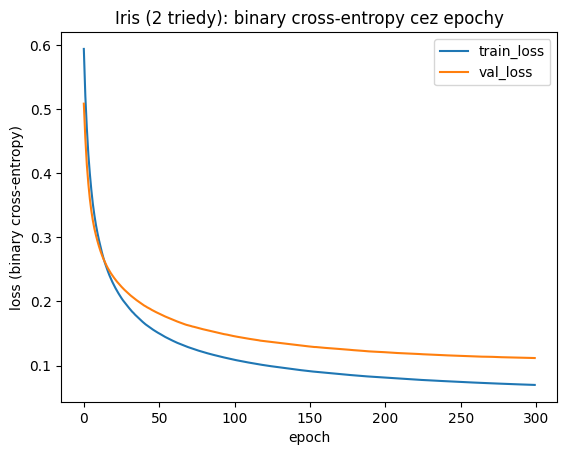

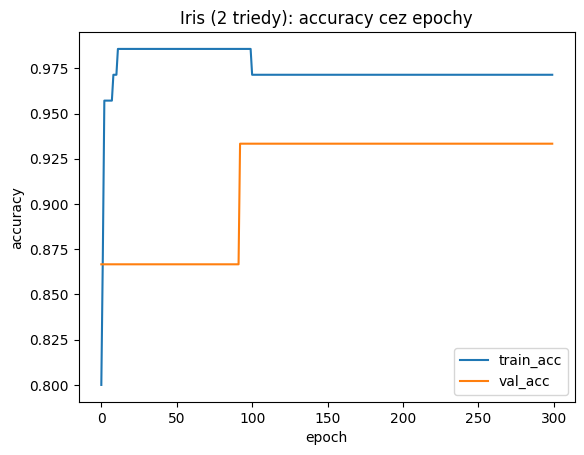

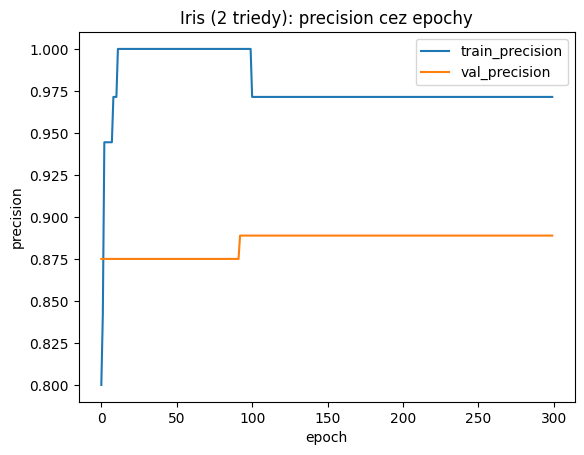

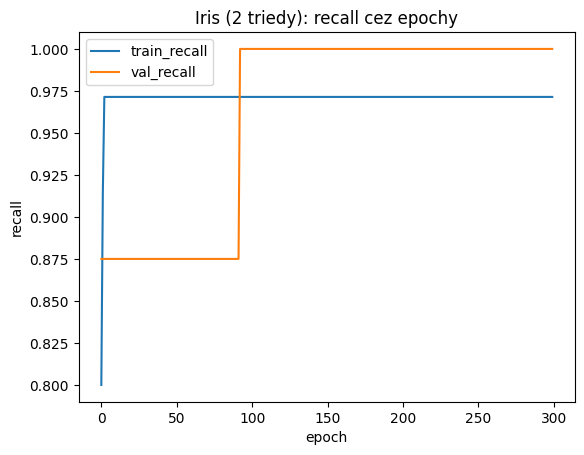

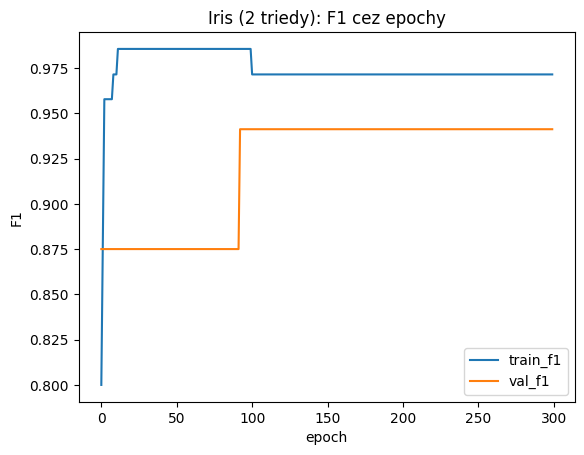

In [ ]:
# @title 10) Grafy učenia
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss (binary cross-entropy)")
plt.title("Iris (2 triedy): binary cross-entropy cez epochy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Iris (2 triedy): accuracy cez epochy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_precision"], label="train_precision")
plt.plot(history["val_precision"], label="val_precision")
plt.xlabel("epoch")
plt.ylabel("precision")
plt.title("Iris (2 triedy): precision cez epochy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_recall"], label="train_recall")
plt.plot(history["val_recall"], label="val_recall")
plt.xlabel("epoch")
plt.ylabel("recall")
plt.title("Iris (2 triedy): recall cez epochy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_f1"], label="train_f1")
plt.plot(history["val_f1"], label="val_f1")
plt.xlabel("epoch")
plt.ylabel("F1")
plt.title("Iris (2 triedy): F1 cez epochy")
plt.legend()
plt.show()

---
## 11) Vyhodnotenie na validácii: confusion matrix + finálne metriky

Confusion matrix budeme čítať takto:

- riadky = **skutočná trieda**
- stĺpce = **predikovaná trieda**

Teda:

\[
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
\]

Z nej vieme dopočítať:
- `accuracy`
- `precision`
- `recall`
- `F1`

Pri binárnej klasifikácii je to veľmi názorný spôsob, ako ukázať, **v akom type prípadov sa model mýli**.


Validation: acc=0.950 | precision=1.000 | recall=0.900 | F1=0.947

Confusion matrix [riadky=true, stĺpce=pred]:
[[10  0]
 [ 1  9]]


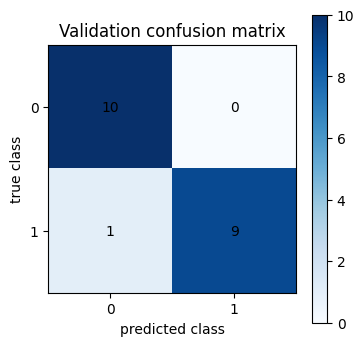

In [ ]:
# @title 11) Confusion matrix + finálne metriky na validačnej množine
model.eval()

y_val_true = []
y_val_pred = []
y_val_prob = []

with torch.no_grad():
    for Xb, yb_oh, yb_int in val_loader:
        Xb = Xb.to(device)
        yb_int = yb_int.to(device)

        logits = model(Xb)
        probs = torch.sigmoid(logits).squeeze(1)
        preds = (probs >= threshold).long()

        y_val_true.extend(yb_int.cpu().numpy().tolist())
        y_val_pred.extend(preds.cpu().numpy().tolist())
        y_val_prob.extend(probs.cpu().numpy().tolist())

val_metrics = metric_dict_from_predictions(y_val_true, y_val_pred)
cm = val_metrics["cm"]

print_metric_summary("Validation", val_metrics)
print()
print("Confusion matrix [riadky=true, stĺpce=pred]:")
print(cm)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Validation confusion matrix")
plt.xlabel("predicted class")
plt.ylabel("true class")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.show()

### Mini úlohy na skúšanie
- Zmeň `learning_rate` a sleduj, čo to spraví s krivkou `train_loss` a `val_loss`.
- Zmeň threshold z `0.5` na `0.3` alebo `0.7` a sleduj, čo sa stane s `precision` a `recall`.
- Skús inú veľkosť batchu v `DataLoader`.
- Zmeň počet epoch.
- Vypni `early stopping` a porovnaj priebeh učenia.
- Pozri sa na confusion matrix a skús slovami vysvetliť, aký typ chýb model robí.
- Skús vysvetliť, prečo aj pri binárnej klasifikácii nestačí vždy pozerať len na samotnú `accuracy`.
